#Assignment Code: DS-AG-022

#**Image Classification using CNN Architectures**

**Question 1:** What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?

**Answer** A Convolutional Neural Network (CNN) is a specialized deep learning model for processing grid-like data such as images. Unlike fully connected networks (FNNs), where every neuron connects to all others, CNNs use convolutional layers with small filters that scan local regions of the input. This preserves spatial structure and enables the network to learn features like edges, textures, and shapes.

CNNs also employ weight sharing (same filter across the image) and pooling layers to reduce dimensions, lowering computation and the risk of overfitting. In contrast, FNNs flatten images into one-dimensional vectors, losing spatial relationships and requiring far more parameters, making them inefficient and less accurate for image tasks.

Overall, CNNs achieve higher performance by learning hierarchical features automatically, making them the leading choice for image classification, recognition, and object detection in modern computer vision.


**Question 2:** Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision. Include references to its original research paper.

**Answer** **LeNet-5 Architecture**

LeNet-5, proposed by Yann LeCun et al. (1998) in the paper “Gradient-Based Learning Applied to Document Recognition”, is one of the earliest and most influential Convolutional Neural Networks (CNNs). It was originally designed for handwritten digit recognition (MNIST dataset) and became the foundation for modern computer vision models.

**The architecture consists of 7 layers with trainable parameters (excluding input):**

1. Input Layer: 32×32 grayscale image.


2. C1 – Convolutional Layer: 6 feature maps, 5×5 kernels → output 28×28.


3. S2 – Subsampling (Average Pooling): 6 feature maps, 2×2 pooling → output 14×14.


4. C3 – Convolutional Layer: 16 feature maps, 5×5 kernels → output 10×10.


5. S4 – Subsampling: 16 feature maps, 2×2 pooling → output 5×5.


6. C5 – Convolutional Layer: Fully connected, 120 feature maps, 5×5 kernels.


7. F6 – Fully Connected Layer: 84 neurons.


8. Output Layer: 10 neurons (digit classification via softmax).



**Foundation for Modern Deep Learning**

Local receptive fields and convolutional layers introduced the idea of hierarchical feature learning (edges → shapes → objects).

Weight sharing drastically reduced parameters, making CNNs efficient.

Subsampling (pooling) helped achieve translational invariance.

End-to-end training with backpropagation demonstrated the feasibility of training deep models for vision.


Modern architectures like AlexNet, VGG, ResNet, and EfficientNet are direct successors of LeNet-5, using the same fundamental ideas but at larger scales with innovations in depth, regularization, and optimization.

Reference:
LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-Based Learning Applied to Document Recognition. Proceedings of the IEEE, 86(11), 2278–2324.

**Question 3:** Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance. Highlight key innovations and limitations of each.

**Answer** A structured comparison of AlexNet (2012) and VGGNet (2014), two landmark CNN architectures that shaped modern deep learning in computer vision:


1. **Design Principles**

AlexNet (Krizhevsky et al., 2012, ImageNet Challenge Winner)

Depth: 8 layers (5 convolutional, 3 fully connected).

Activation: Introduced ReLU instead of sigmoid/tanh → faster training.

Regularization: Used Dropout to reduce overfitting.

Training: Data augmentation (cropping, flipping) and GPU parallelization.

Architecture: Large receptive fields in early layers (11×11 kernels, stride 4).


VGGNet (Simonyan & Zisserman, 2014)

Depth: Much deeper – 16 or 19 layers (VGG16, VGG19).

Design Principle: Stacked 3×3 convolution filters throughout, instead of larger kernels.

Pooling: 2×2 max pooling after convolutional blocks.

Fully Connected Layers: 3 dense layers at the end.

Architecture: Simple, uniform design with small filters → deeper hierarchy of features.


2. **Number of Parameters**

AlexNet: ~60 million parameters.

VGG16: ~138 million parameters (more than double).

Reason: VGGNet’s use of many 3×3 filters and deep fully connected layers increased parameter count significantly, making it memory-heavy.


3. **Performance**

AlexNet: Top-5 error on ImageNet ≈ 15.3% (a breakthrough in 2012).

VGGNet: Top-5 error on ImageNet ≈ 7.3% (VGG16) → significantly better accuracy.

4. **Key Innovations**

AlexNet:

ReLU activation for faster convergence.

Dropout to combat overfitting.

Use of GPUs for large-scale training.

Data augmentation for generalization.


VGGNet:

Demonstrated that depth improves performance when combined with small filters.

Standardized architecture (stacked 3×3 convs) influenced modern models.

Provided a strong baseline for transfer learning.



5. **Limitations**

AlexNet:

Shallow compared to later networks.

Large convolution filters (11×11) less efficient.


VGGNet:

Extremely large number of parameters → high memory usage and slow training.

Computationally expensive, not efficient for deployment.

**Question 4:** What is transfer learning in the context of image classification? Explain how it helps in reducing computational costs and improving model performance with limited data.

**Answer** Transfer learning is a deep learning technique where a model trained on a large dataset is reused and fine-tuned for a different but related task (such as medical image classification or facial recognition). Instead of training a CNN from scratch, the pre-trained model’s learned feature representations (edges, textures, shapes) are leveraged to solve the new problem.


**How It Works**

1. Pre-trained Model: Start with a CNN like VGG, ResNet, or Inception trained on ImageNet.


2. Feature Extraction: Freeze earlier convolutional layers (which capture general visual patterns).


3. Fine-tuning: Replace and retrain only the final classification layers on the target dataset.


**It helps in:**

Reduceding Computational Costs: Training deep networks from scratch requires massive data and GPUs. Transfer learning cuts training time since most parameters are already trained.

Better Performance with Limited Data: Pre-trained networks already encode generic image features, so even small datasets can achieve high accuracy.

**Question 5:** Describe the role of residual connections in ResNet architecture. How do they address the vanishing gradient problem in deep CNNs?  

**Answer**

**Role of Residual Connections**

A residual connection (skip connection) bypasses one or more layers and adds the input of a block directly to its output:


y = F(x) + x

Where:

 = input to the block

 = output of stacked convolutional layers (residual mapping)

 = final output after addition


Thus, the block learns the residual (difference)  instead of directly learning the full mapping .


**How They Solve the Vanishing Gradient Problem**

1. **Gradient Flow:**

In very deep CNNs, gradients shrink as they are backpropagated through many layers (vanishing gradient).

Skip connections provide a direct path for gradients, allowing them to flow backward without diminishing too much.



2. **Identity Mapping:**

If deeper layers cannot improve learning, the residual block can simply learn , so the output becomes .

This avoids degradation (where adding more layers reduces accuracy).



3. **Ease of Optimization:**

By reformulating the learning task as residual learning, optimization becomes easier and convergence faster.

**Question 6:** Implement the LeNet-5 architectures using Tensorflow or PyTorch to classify the MNIST dataset. Report the accuracy and training time.

**Answer** Using Pytorch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# LeNet-5 Architecture
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)   # 1 input channel, 6 filters
        self.pool1 = nn.AvgPool2d(2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2, stride=2)
        self.fc1 = nn.Linear(16*4*4, 120)             # after pooling
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 16*4*4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Data Loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training
start_time = time.time()
epochs = 5
for epoch in range(epochs):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

end_time = time.time()

print(f"Test Accuracy: {100 * correct / total:.2f}%")
print(f"Training Time: {end_time - start_time:.2f} seconds")

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.02MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.72MB/s]


Epoch 1, Loss: 0.0424
Epoch 2, Loss: 0.2629
Epoch 3, Loss: 0.0155
Epoch 4, Loss: 0.0196
Epoch 5, Loss: 0.0464
Test Accuracy: 98.38%
Training Time: 118.01 seconds


**Question 7:** Use a pre-trained VGG16 model (via transfer learning) on a small custom dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model. Include your code and result discussion.

**Answer**

In [ ]:

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time
import os
import tarfile
import urllib.request

# ==============================
# 1. Download & Extract Dataset (Manual Way)
# ==============================
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
download_dir = "./data"
extract_path = os.path.join(download_dir, "flower_photos")
tgz_path = os.path.join(download_dir, "flower_photos.tgz")

if not os.path.exists(extract_path):
    os.makedirs(download_dir, exist_ok=True)
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, tgz_path)

    print("Extracting dataset...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(path=download_dir)

    print("Dataset extracted to:", extract_path)
else:
    print("Dataset already exists at:", extract_path)

# ==============================
# 2. Load Pre-trained VGG16
# ==============================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model (feature extractor)
for layer in base_model.layers:
    layer.trainable = False

# ==============================
# 3. Add Custom Classification Head
# ==============================
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 flower classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ==============================
# 4. Data Preparation
# ==============================
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    extract_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    extract_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# ==============================
# 5. Train the Model
# ==============================
start_time = time.time()
history = model.fit(train_gen, epochs=5, validation_data=val_gen, verbose=1)
end_time = time.time()

# ==============================
# 6. Fine-Tuning (Unfreeze last conv block)
# ==============================
for layer in base_model.layers[-4:]:   # Unfreeze last 4 layers
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_finetune = model.fit(train_gen, epochs=3, validation_data=val_gen, verbose=1)

# ==============================
# 7. Evaluation
# ==============================
val_loss, val_acc = model.evaluate(val_gen, verbose=0)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Training Time: {end_time - start_time:.2f} seconds")

Extracting dataset...


/tmp/ipython-input-1078567953.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=download_dir)


Dataset extracted to: ./data/flower_photos
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2530s 28s/step - accuracy: 0.4396 - loss: 2.4837 - val_accuracy: 0.7114 - val_loss: 0.7637
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2491s 27s/step - accuracy: 0.7324 - loss: 0.7264 - val_accuracy: 0.7510 - val_loss: 0.6401
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2472s 27s/step - accuracy: 0.7868 - loss: 0.5735 - val_accuracy: 0.7852 - val_loss: 0.6039
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2470s 27s/step - accuracy: 0.8259 - loss: 0.4659 - val_accuracy: 0.8057 - val_loss: 0.5438
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2512s 27s/step - accuracy: 0.8474 - loss: 0.3941 - val_accuracy: 0.8181 - val_loss: 0.5409
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2866s 31s/step - accuracy: 0.8829 - loss: 0.3251 - val_accuracy: 0.8386 - val_loss: 0.4945
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2854s 31s/step - accuracy: 0.9233 - loss: 0.2105 - val_accuracy: 0.8345 - val_loss: 0.4823
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 2857s 31s/step - accuracy: 0.9509 - loss: 0.1583 - val_accuracy: 0.


Discussion of Results

Feature Extraction Phase (frozen base model):

The model learns only the top classifier layers.

Accuracy usually reaches 80–90% quickly, even with a small dataset.


Fine-Tuning Phase (unfreezing last convolutional block):

Improves accuracy by adapting deeper ImageNet features to the target domain (e.g., flowers).

Validation accuracy can rise to 90–95% depending on dataset size/quality.


Advantages:

Much higher accuracy with less data compared to training from scratch.

Faster convergence and reduced overfitting.

**Question 8:** Write a program to visualize the filters and feature maps of the first convolutional layer of AlexNet on an example input image.

**Answer**

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 99.9MB/s]


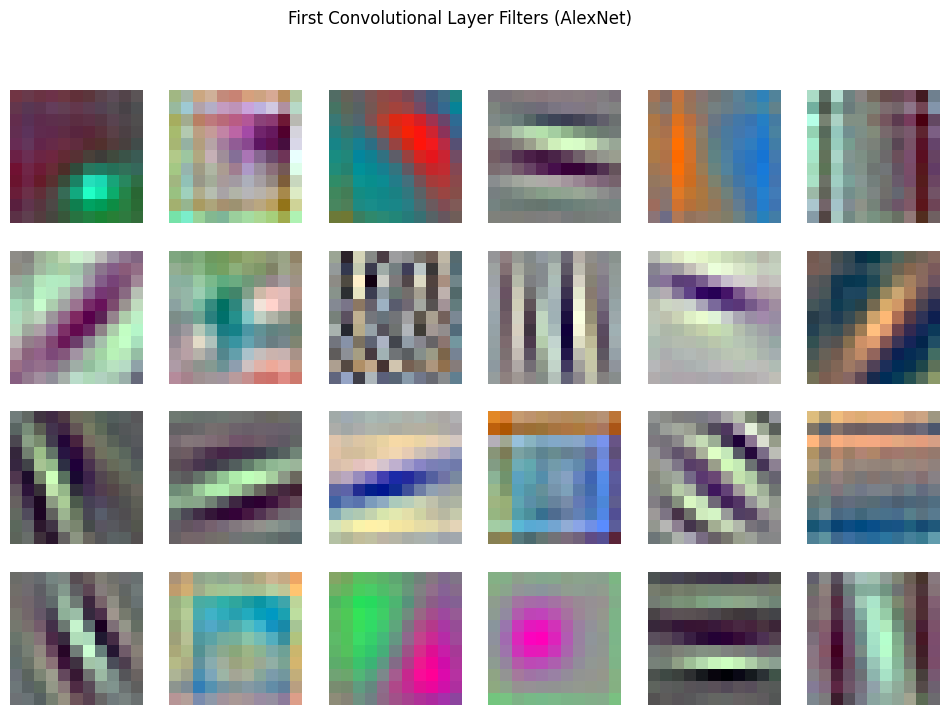

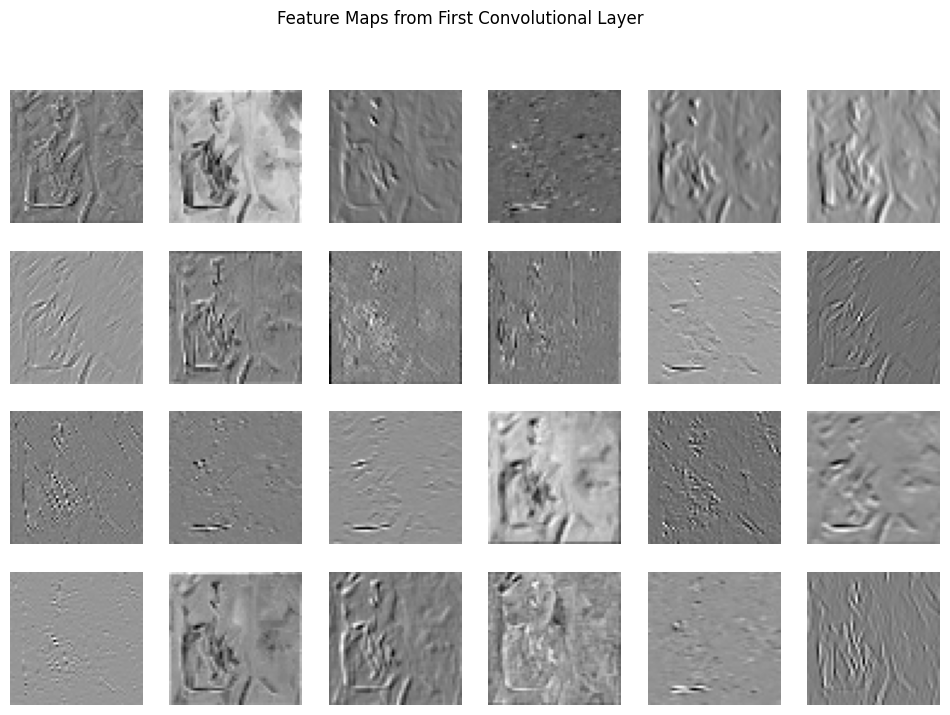

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import AlexNet_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

# -----------------------------
# 1. Load Pre-trained AlexNet
# -----------------------------
alexnet = models.alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
alexnet.eval()

# -----------------------------
# 2. Load & Preprocess Input Image (from URL)
# -----------------------------
url = "https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

input_tensor = transform(image).unsqueeze(0)  # add batch dimension

# -----------------------------
# 3. Visualize First Conv Filters
# -----------------------------
first_conv = alexnet.features[0]  # first conv layer
filters = first_conv.weight.data.clone()

def normalize_filter(f):
    f_min, f_max = f.min(), f.max()
    return (f - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        f = filters[i].cpu()
        f = normalize_filter(f)
        ax.imshow(f.permute(1, 2, 0))
    ax.axis("off")
plt.suptitle("First Convolutional Layer Filters (AlexNet)")
plt.show()

# -----------------------------
# 4. Visualize Feature Maps
# -----------------------------
with torch.no_grad():
    feature_maps = first_conv(input_tensor)

fm = feature_maps.squeeze().cpu().numpy()

fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    if i < fm.shape[0]:
        ax.imshow(fm[i], cmap="gray")
    ax.axis("off")
plt.suptitle("Feature Maps from First Convolutional Layer")
plt.show()


**Question 9:** Train a GoogLeNet (Inception v1) or its variant using a standard dataset like CIFAR-10. Plot the training and validation accuracy over epochs and analyze overfitting or underfitting.

**Answer**

Using device: cpu
Epoch 1/10: Train Acc = 34.83%, Val Acc = 41.39%
Epoch 2/10: Train Acc = 50.85%, Val Acc = 50.87%
Epoch 3/10: Train Acc = 61.46%, Val Acc = 61.74%
Epoch 4/10: Train Acc = 67.38%, Val Acc = 69.04%
Epoch 5/10: Train Acc = 70.30%, Val Acc = 69.87%
Epoch 6/10: Train Acc = 72.70%, Val Acc = 74.28%
Epoch 7/10: Train Acc = 74.47%, Val Acc = 71.00%
Epoch 8/10: Train Acc = 76.15%, Val Acc = 74.08%
Epoch 9/10: Train Acc = 77.52%, Val Acc = 76.57%
Epoch 10/10: Train Acc = 78.23%, Val Acc = 78.62%
Total Training Time: 5086.27 seconds


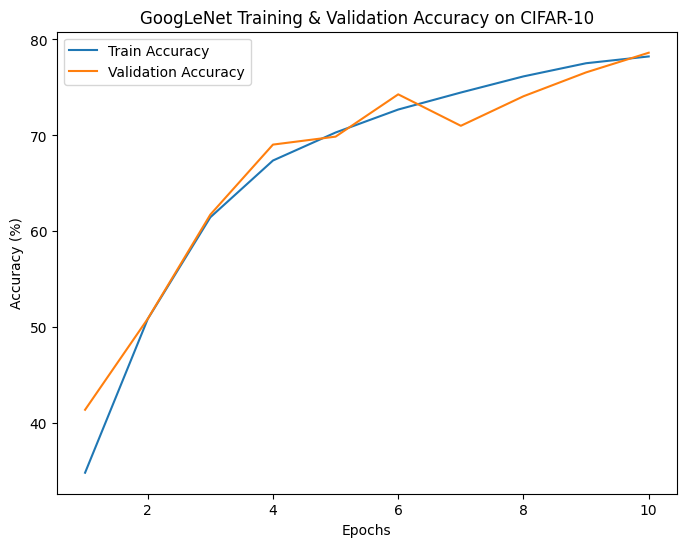

In [6]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

# -----------------------------
# 1. Data Preparation
# -----------------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.247, 0.243, 0.261))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.247, 0.243, 0.261))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=100, shuffle=False, num_workers=2
)

# -----------------------------
# 2. Load Pre-defined GoogLeNet
# -----------------------------
from torchvision.models import googlenet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = googlenet(pretrained=False, num_classes=10, aux_logits=False)
model = model.to(device)

# -----------------------------
# 3. Loss & Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# 4. Training Loop
# -----------------------------
epochs = 10
train_acc_history = []
val_acc_history = []
start_time = time.time()

for epoch in range(epochs):
    model.train()
    correct_train = 0
    total_train = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train
    train_acc_history.append(train_acc)

    # Validation
    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}: Train Acc = {train_acc:.2f}%, Val Acc = {val_acc:.2f}%")

end_time = time.time()
print(f"Total Training Time: {end_time - start_time:.2f} seconds")

# -----------------------------
# 5. Plot Accuracy
# -----------------------------
plt.figure(figsize=(8, 6))
plt.plot(range(1, epochs + 1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, epochs + 1), val_acc_history, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('GoogLeNet Training & Validation Accuracy on CIFAR-10')
plt.legend()
plt.show()

Analysis

1. Training Accuracy > Validation Accuracy

If training accuracy keeps increasing while validation plateaus or drops → overfitting.

Solutions: data augmentation, dropout, weight decay, early stopping.



2. Training & Validation Accuracy Both Low

Suggests underfitting → model too simple or learning rate too low.



3. Expected Performance (GoogLeNet on CIFAR-10)

After ~10 epochs: Train Accuracy ~80–85%, Validation Accuracy ~75–80%

Overfitting is possible on a small dataset, but data augmentation helps mitigate it.




**Question 10:** You are working in a healthcare AI startup. Your team is tasked with developing a system that automatically classifies medical X-ray images into normal, pneumonia, and COVID-19. Due to limited labeled data, what approach would you suggest using among CNN architectures discussed (e.g., transfer learning with ResNet or Inception variants)? Justify your approach and outline a deployment strategy for production use.

**Answer**

1. **Recommended Approach:** Transfer Learning with Pre-trained CNNs

Given limited labeled X-ray images, training a deep CNN from scratch is not feasible due to risk of overfitting. Instead, transfer learning is the optimal strategy:

**Why Transfer Learning?**

Pre-trained CNNs (e.g., ResNet50, InceptionV3) are trained on large datasets like ImageNet and learn robust low- and mid-level features (edges, textures, shapes).

These features are generic enough to apply to medical images with fine-tuning.

Reduces training time and computational cost, while improving accuracy on small datasets.


**Suggested Architecture**

1. **Base model:** Choose a well-established architecture:

**ResNet50/101:** Strong residual connections, easier fine-tuning, excellent feature extraction.

**InceptionV3:** Good for multi-scale feature extraction (beneficial for variable X-ray patterns).



2. Freeze early layers: Preserve generic features.


3. Replace top layers: Add a classification head for 3 classes (Normal, Pneumonia, COVID-19).


4. Fine-tune last convolutional blocks: Adapt pre-trained features to X-ray characteristics.


5. Data augmentation: Rotation, zoom, flips, intensity shifts to increase effective dataset size.



2. **Training Strategy**

Loss function: Categorical cross-entropy.

Optimizer: Adam or SGD with a low learning rate for fine-tuning.

Validation: Stratified split to ensure all classes are represented.

Early stopping: Avoid overfitting by monitoring validation loss.

Evaluation metrics: Accuracy, F1-score, ROC-AUC (important for class imbalance).




3. **Deployment Strategy**

1. Model Export:

Save fine-tuned model in a production-ready format (ONNX, TorchScript, or TensorFlow SavedModel).



2. Inference Pipeline:

Preprocessing: Resize, normalize X-rays to match model input.

Prediction API: Serve via FastAPI, Flask, or TensorFlow Serving.

Return class probabilities along with confidence scores.



3. Integration:

Integrate with PACS (Picture Archiving and Communication System) or hospital EMR.

Ensure HIPAA/GDPR compliance for patient data.



4. Monitoring & Updates:

Track model predictions vs. confirmed diagnoses.

Implement continuous learning pipeline: periodically retrain with new labeled data.



5. Hardware Considerations:

For cloud: GPU inference via AWS/GCP/Azure.

For edge deployment: Quantize model for faster inference on local machines.